# Convert LeHaMoC comoving SED to observed flux

This notebook reads the photon spectrum saved by `LeHaMoC.py` in the comoving frame and converts it to observed `νFν` using the Doppler factor and redshift. Optional EBL absorption can be included through `ebltable`. If no EBL absorption is included ebl_model should be set to None `ebl_model = None`

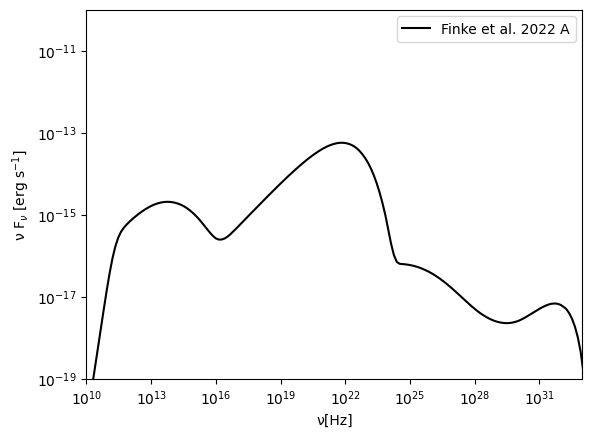

In [19]:
import numpy as np
import astropy.units as u
import pandas as pd
import matplotlib.pyplot as plt
from astropy import constants as const
from astropy.cosmology import Planck18 as cosmo


#######################
#constants# 
#######################
G = (const.G).cgs.value       
c = (const.c).cgs.value     
Ro = (const.R_sun).cgs.value            
Mo = (const.M_sun).cgs.value       
yr = (u.yr).to(u.s)                
kpc = (u.kpc).to(u.cm)             
pc = (u.pc).to(u.cm)              
m_pr = (u.M_p).to(u.g)         
m_el = (u.M_e).to(u.g)         
kb = (const.k_B).cgs.value
h = (const.h).cgs.value 
q = (const.e.gauss).value                
sigmaT = (const.sigma_T).cgs.value               
eV = (u.eV).to(u.erg)   
B_cr = 2*np.pi*m_el**2*c**3/(h*q)

# Read the Parameters.txt file
fileName = "Parameters.txt"
fileObj = open(fileName)
params = {}
for line in fileObj:
    line=line.strip()
    key_value = line.split("=")
    params[key_value[0].strip()] = float(key_value[1].strip())
    
time_init = float(params['time_init']) #R0/c
time_end = float(params['time_end']) #R0/c
step_alg = float(params['step_alg']) #R0/c
grid_nu = int(float(params['grid_nu']))    
grid_g_el = int(float(params['grid_g_el']))
grid_g_pr = int(float(params['grid_g_pr']))

R0 = 10**float(params['R0']) #log
step_alg = float(params['step_alg']) #R0/c
M_F = float(params['B0']) 
delta = float(params["delta"])
# Read Outpuf files
# LeHaMoC code results
El_dis_lemoc_t3 = pd.read_csv("Pairs_Distribution.txt", names=["logx","logy"], sep=" ",  skiprows=0) 
Ph_dis_lemoc_t3 = pd.read_csv("Photons_Distribution.txt", names=["logx","logy"], sep=" ",  skiprows=0) 

nu_tot = np.array(10**Ph_dis_lemoc_t3["logx"])
Spec_temp_tot = np.array(10**Ph_dis_lemoc_t3["logy"])
g_el  = np.array(10**El_dis_lemoc_t3["logx"])
N_el  = np.array(10**El_dis_lemoc_t3["logy"])


def leha_sed_to_observer(nu_prime_hz, nuLnu_prime_erg_s, z, delta_D, ebl_model=None, ebl_scale=1.0, cosmology=cosmo,):
    """
    Convert LeHaMoC comoving SED to observed nuFnu, optionally with EBL absorption.

    Parameters
    ----------
    nu_prime_hz : Comoving frequency grid [Hz].
    nuLnu_prime_erg_s : Comoving SED nu' L'_{nu'} [erg/s].
    z : Source redshift.
    delta_D : Doppler factor.
    ebl_model : Example: 'finke2022', 'saldana-lopez', 'dominguez', 'franceschini2017'. If None, no EBL attenuation is applied.
    ebl_scale : Multiplier alpha for tau_EBL. Usually alpha=1.
    cosmology : Cosmology used to compute luminosity distance.

    Returns
    -------
    nu_obs_hz : Observed frequency [Hz].
    nuFnu_obs : Observed attenuated SED [erg cm^-2 s^-1].
    nuFnu_int : Observed intrinsic SED before EBL [erg cm^-2 s^-1].
    tau_ebl : EBL optical depth.
    """

    nu_prime_hz = np.asarray(nu_prime_hz, dtype=float)
    nuLnu_prime_erg_s = np.asarray(nuLnu_prime_erg_s, dtype=float)

    # Frequency transformation
    nu_obs_hz = delta_D * nu_prime_hz / (1. + z)

    # Luminosity distance
    dL_cm = cosmology.luminosity_distance(z).to_value("cm")

    # Intrinsic observed SED, before EBL
    nuFnu_int = delta_D**4 * nuLnu_prime_erg_s / (4. * np.pi * dL_cm**2)

    # Default: no EBL
    tau_ebl = np.zeros_like(nu_obs_hz)

    if ebl_model is not None:
        from ebltable.tau_from_model import OptDepth

        # ebltable expects observed energy in TeV
        E_obs_TeV = (h * nu_obs_hz * u.erg).to_value(u.TeV)

        tau_model = OptDepth.readmodel(ebl_model)

        # Avoid asking the table for radio/optical/X-ray frequencies.
        # EBL attenuation matters only for gamma rays.
        gamma_mask = E_obs_TeV > 1e-6  # 1 MeV in TeV units; safely low

        tau_ebl[gamma_mask] = np.squeeze(tau_model.opt_depth(z, E_obs_TeV[gamma_mask]))
        tau_ebl = np.maximum(tau_ebl, 0.0)
    attenuation = np.exp(-ebl_scale * tau_ebl)
    nuFnu_obs = nuFnu_int * attenuation
    return nu_obs_hz, nuFnu_obs, nuFnu_int, tau_ebl
#delta =  You can define delta also here.
redshift = 0.186
LIST_ALL = leha_sed_to_observer(nu_tot[-grid_nu:], Spec_temp_tot[-grid_nu:], redshift, 24.2, ebl_model=None, ebl_scale=1.0, cosmology=cosmo,)
plt.loglog(LIST_ALL[0], LIST_ALL[1],label="Finke et al. 2022 A", c = "k") 
plt.ylabel("ν F$_ν$ [erg s$^{-1}$]")
plt.xlabel("ν[Hz]")

plt.ylim(10**(-19.),10**(-10.))
plt.xlim(10**(10.),10**(33.))
plt.legend(fontsize=10)

In [22]:
Spec_temp_tot[-grid_nu:]

array([1.66416099e-230, 6.90309006e-030, 2.45917478e+027, 6.21365481e+027,
       1.59488302e+028, 4.18645792e+028, 1.13904279e+029, 3.20642136e+029,
       9.21502013e+029, 2.67914230e+030, 7.82087909e+030, 2.28327779e+031,
       6.65727505e+031, 1.93601429e+032, 5.59813481e+032, 1.59947832e+033,
       4.46907865e+033, 1.16562905e+034, 2.68022179e+034, 5.21492579e+034,
       8.51607094e+034, 1.19099082e+035, 1.49553879e+035, 1.79056210e+035,
       2.09944400e+035, 2.42943103e+035, 2.78557712e+035, 3.16862118e+035,
       3.56821658e+035, 3.98315790e+035, 4.40435488e+035, 4.82058878e+035,
       5.21882267e+035, 5.57036340e+035, 5.86505255e+035, 6.09544597e+035,
       6.25054861e+035, 6.32209298e+035, 6.29668937e+035, 6.16305870e+035,
       5.94322044e+035, 5.64481469e+035, 5.27875151e+035, 4.85856619e+035,
       4.37905321e+035, 3.87931052e+035, 3.37832840e+035, 2.89247043e+035,
       2.43590947e+035, 2.01607047e+035, 1.64905845e+035, 1.34545216e+035,
       1.10637882e+035, 9

(1e+38, 1e+44)

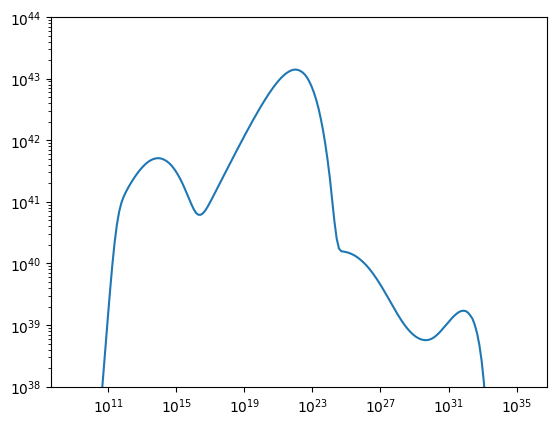

In [25]:
plt.loglog(nu_tot[-grid_nu:]*30., 30**4.*Spec_temp_tot[-grid_nu:])
plt.ylim(10**38.,10**44.)

In [29]:
Nu_dis_lemoc_t4

,logx,logy
0,24.383454,-inf
1,24.628352,-229.229713
2,24.873250,-229.938200
3,25.118148,-230.642498
4,25.363046,-231.349839
...,...,...
495,35.403863,-270.228310
496,35.648760,-270.228310
497,35.893658,-270.228310
498,36.138556,-270.228310


In [31]:
iplot

10

(1e+37, 2e+40)

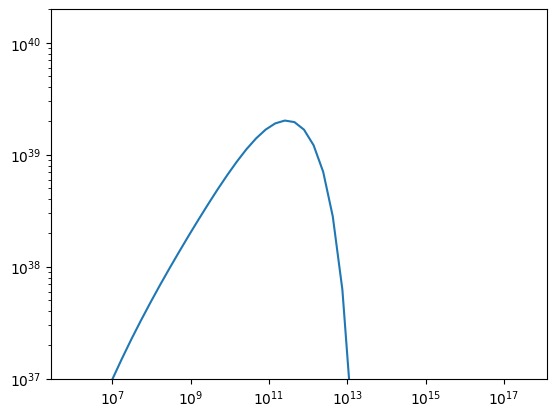

In [39]:
### Read Output files

import LeHaMoC_f as f
# LeHaMoC code results
Nu_dis_lemoc_t4 = pd.read_csv("Neutrinos_Distribution.txt", names=["logx","logy"], sep=" ",  skiprows=0) 

# Plots showing final snapshot (steady state)

# Select final snapshot from LeMoC results
iplot = int(time_end/step_alg)

nu_nu = np.array(10**Nu_dis_lemoc_t4["logx"][(iplot-1)*50:iplot*50])
Nu_nu_plot = np.array(10**Nu_dis_lemoc_t4["logy"][(iplot-1)*50:iplot*50])

plt.loglog(h*nu_nu[1:-1]/(m_el*c**2.)*30.,np.multiply(Nu_nu_plot[1:-1],(h*nu_nu[1:-1])**2./h)*4.*np.pi/3.*R0**2.*c/f.Volume(R0)*30**4.)
plt.ylim(10**(37.),2.*10**40.)

In [15]:
!python LeHaMoC.py

Progress...: 100%|██████████████████████████████| 10/10 [00:13<00:00,  1.31s/it]
--- 13.18 seconds ---


In [34]:
#Functions for making code comparison plots with residual panels
def plotting_res_1(x1,y1,x2,y2,axlabel_y1,axlabel_x1,xlim_l,xlim_u,ylim_l,ylim_u,label1,label2,filename):
    tot_fig,axes = plt.subplots(2, 1, gridspec_kw={'height_ratios': [2, 1]},sharex=True, sharey=False,constrained_layout=True, figsize=(8,6))

    plt.subplots_adjust(wspace=1, hspace=0.1)

    ax = plt.subplot(211)
    ax.set_yscale("log", nonpositive='clip')
    ax.set_xscale("log", nonpositive='clip')
    plt.plot(x1,y1,c='orchid',alpha=1.,label=label1,linewidth=3)
    plt.plot(x2,y2,label=label2,linewidth=3,ls="-.",c="yellowgreen")
    ax.set_ylabel(axlabel_y1,fontsize=15)
    ax.tick_params(axis='x', which='major', labelsize=15)
    ax.tick_params(axis='y', which='major', labelsize=15) 
    ax.xaxis.set_tick_params(which='major', size=10, width=2, direction='in', top='on')
    ax.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
    ax.yaxis.set_tick_params(which='major', size=10, width=2, direction='in', right='on')
    ax.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')
    ax.set_xlim(xlim_l,xlim_u)
    ax.set_ylim(ylim_l,ylim_u)
    plt.legend(fontsize=15)

    ax2 = plt.subplot(212)
    ax2.tick_params(axis='x', which='major', labelsize=15)
    ax2.tick_params(axis='y', which='major', labelsize=15) 
    ax2.xaxis.set_tick_params(which='major', size=10, width=2, direction='in', top='on')
    ax2.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
    ax2.yaxis.set_tick_params(which='major', size=10, width=2, direction='in', right='on')
    ax2.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')
    ax2.plot(x2,np.divide(np.interp(x2,x1,y1),y2),color='black',linewidth=3)
    ax2.plot([(x2[0]-1),(x2[-1])+1],[1,1],'--', alpha=0.6,color='red')
    ax2.set_xscale("log", nonpositive='clip')
    ax2.set_yscale("log", nonpositive='clip')
    ax2.set_xlim(xlim_l,xlim_u)
    ax2.set_ylim(10**(-1.),10**(1.))
    plt.ylabel(r'$\chi$=Y$_{ATHEνA}$/$Y_{LeHaMoC}$',fontsize=15)
    plt.xlabel(axlabel_x1,fontsize=15)
    plt.savefig(filename,dpi=300)

def plotting_res_2(x1,y1,x2,y2,x3,y3,axlabel_y1,axlabel_x1,xlim_l,xlim_u,ylim_l,ylim_u,label1,label2,label3,filename):
    tot_fig,axes = plt.subplots(2, 1, gridspec_kw={'height_ratios': [2, 1]},sharex=True, sharey=False,constrained_layout=True, figsize=(8,6))

    plt.subplots_adjust(wspace=1, hspace=0.1)

    ax = plt.subplot(211)
    ax.set_yscale("log", nonpositive='clip')
    ax.set_xscale("log", nonpositive='clip')
    plt.plot(x1,y1,c='orchid',alpha=1.,label=label1,linewidth=3)
    plt.plot(x2,y2,label=label2,linewidth=3,ls="-.",c="yellowgreen")
    plt.plot(x3,y3,label=label3,linewidth=3,ls="dashed",c="grey")
    ax.set_ylabel(axlabel_y1,fontsize=15)
    ax.tick_params(axis='x', which='major', labelsize=15)
    ax.tick_params(axis='y', which='major', labelsize=15) 
    ax.xaxis.set_tick_params(which='major', size=10, width=2, direction='in', top='on')
    ax.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
    ax.yaxis.set_tick_params(which='major', size=10, width=2, direction='in', right='on')
    ax.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')
    ax.set_xlim(xlim_l,xlim_u)
    ax.set_ylim(ylim_l,ylim_u)
    plt.legend(fontsize=15)

    ax2 = plt.subplot(212)
    ax2.tick_params(axis='x', which='major', labelsize=15)
    ax2.tick_params(axis='y', which='major', labelsize=15) 
    ax2.xaxis.set_tick_params(which='major', size=10, width=2, direction='in', top='on')
    ax2.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
    ax2.yaxis.set_tick_params(which='major', size=10, width=2, direction='in', right='on')
    ax2.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')
    ax2.plot(x2,np.divide(np.interp(x2,x1,y1),y2),color='yellowgreen',ls="-.",linewidth=3)
    ax2.plot(x3,np.divide(np.interp(x3,x1,y1),y3),color='grey',ls="dashed",linewidth=3)

    ax2.plot([(x2[0]-1),(x2[-1])+1],[1,1],'--', alpha=0.6,color='red')
    ax2.set_xscale("log", nonpositive='clip')
    ax2.set_yscale("log", nonpositive='clip')
    ax2.set_xlim(xlim_l,xlim_u)
    ax2.set_ylim(10**(-1.),10**(1.))
    plt.ylabel(r'$\chi$=Y$_{ATHEνA}$/$Y_{LeHaMoC}$',fontsize=15)
    plt.xlabel(axlabel_x1,fontsize=15)
    
    plt.savefig(filename,dpi=300)
    
def plotting_evol(x1,y1,npts,axlabel_y1,axlabel_x1,xlim_l,xlim_u,ylim_l,ylim_u,filename):
    fig,ax = plt.subplots(1,1,figsize=(8,6))
    ax.tick_params(axis='x', which='major', labelsize=15)
    ax.tick_params(axis='y', which='major', labelsize=15) 
    ax.set_xscale("log", nonpositive='clip')
    ax.set_yscale("log", nonpositive='clip')
    
    for i in range(0,int(len(y1)/npts)): 
        ax.plot(x1[i*npts:(i+1)*npts],(x1[i*npts :(i+1)*npts])**2*y1[i*npts:(i+1)*npts],color='k',alpha=0.5)
        
    ax.set_xlabel(axlabel_x1,fontsize=15)
    ax.set_ylabel(axlabel_y1,fontsize=15)    
    ax.set_ylim(ylim_l,ylim_u)
    ax.set_xlim(xlim_l,xlim_u)
    
    plt.savefig(filename,dpi=300)
    
def replace_in_file(filename, key, new_value):
    """
    Replace the value associated with a given key in a text file.

    Parameters:
    - filename (str): The name of the file to be modified.
    - key (str): The key whose value needs to be replaced.
    - new_value (str): The new value to be assigned to the specified key.

    This function reads the content of the file, searches for the specified key,
    and updates its associated value with the provided new_value. The modified content
    is then written back to the same file.

    Note: This function assumes that each key-value pair in the file is defined as
    'key = value' and that there are no leading or trailing whitespaces around the key.
    """
    f = open(filename, "r")
    lines = f.readlines()
    f.close()
    for i, line in enumerate(lines):
        if line.split('=')[0].strip(' \n') == key:
            lines[i] = key + ' = ' + new_value + '\n'
    f = open(filename, "w")
    f.write("".join(lines))
    f.close()

In [35]:
# Read the Parameters.txt file
fileName = "Parameters.txt"
fileObj = open(fileName)
params = {}
for line in fileObj:
    line=line.strip()
    key_value = line.split("=")
    params[key_value[0].strip()] = float(key_value[1].strip())
    
time_init = float(params['time_init']) #R0/c
time_end = float(params['time_end']) #R0/c
step_alg = float(params['step_alg']) #R0/c
grid_nu = int(float(params['grid_nu']))    
grid_g_el = int(float(params['grid_g_el']))
grid_g_pr = int(float(params['grid_g_pr']))

R0 = 10**float(params['R0']) #log
step_alg = float(params['step_alg']) #R0/c
M_F = float(params['B0']) 
delta = float(params["delta"])

#######################
# Execution of LeHaMoC#
#######################
!python LeHaMoC.py

Progress...: 100%|██████████████████████████████| 10/10 [00:10<00:00,  1.07s/it]
--- 10.78 seconds ---


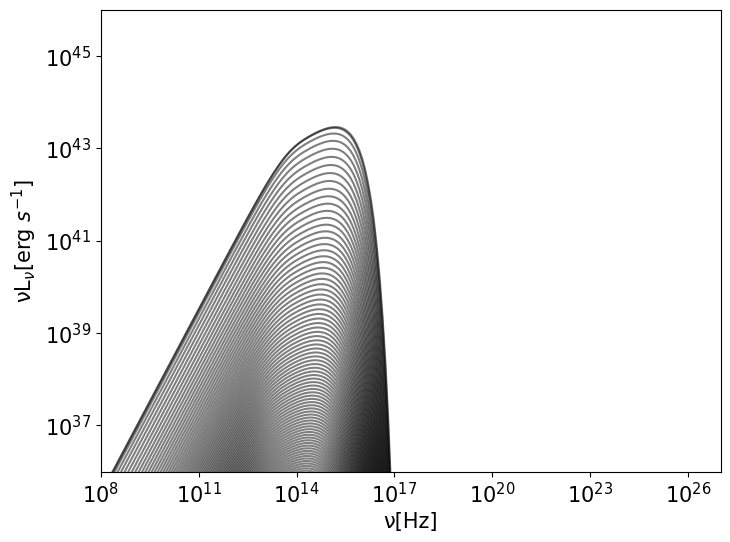

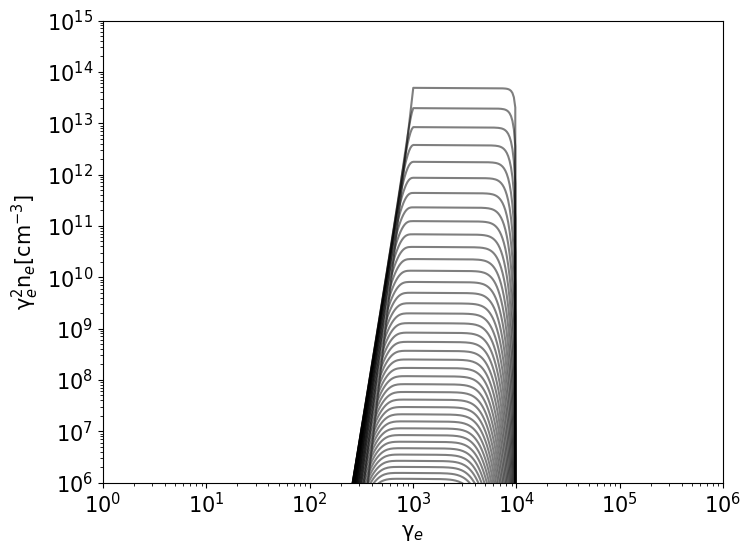

In [5]:
# Read Outpuf files
# LeHaMoC code results
El_dis_lemoc_t3 = pd.read_csv("Pairs_Distribution.txt", names=["logx","logy"], sep=" ",  skiprows=0) 
Ph_dis_lemoc_t3 = pd.read_csv("Photons_Distribution.txt", names=["logx","logy"], sep=" ",  skiprows=0) 

nu_tot = np.array(10**Ph_dis_lemoc_t3["logx"])
Spec_temp_tot = np.array(10**Ph_dis_lemoc_t3["logy"])/nu_tot**2.
g_el  = np.array(10**El_dis_lemoc_t3["logx"])
N_el  = np.array(10**El_dis_lemoc_t3["logy"])

# Plots showing time evolution
plotting_evol(nu_tot,Spec_temp_tot,int(grid_nu), 'νL$_{ν}$[erg $s^{-1}$]',"ν[Hz]",10**8.,10**27.,10**(36.),10**46.,"test1_ph_evol.png")
plotting_evol(g_el, N_el, int(grid_g_el),'γ$_e^2$n$_e$[cm$^{-3}$]',"γ$_{e}$",10**0.,10**6.,10**(6.),10**(15.),"test1_el_evol.png")

In [34]:
plt.loglog(nu_tot[-grid_nu:],Spec_temp_tot[-grid_nu:])

Error in callback <function _draw_all_if_interactive at 0x12f246ac0> (for post_execute), with arguments args (),kwargs {}:


OverflowError: cannot convert float infinity to integer

OverflowError: cannot convert float infinity to integer

<Figure size 640x480 with 1 Axes>

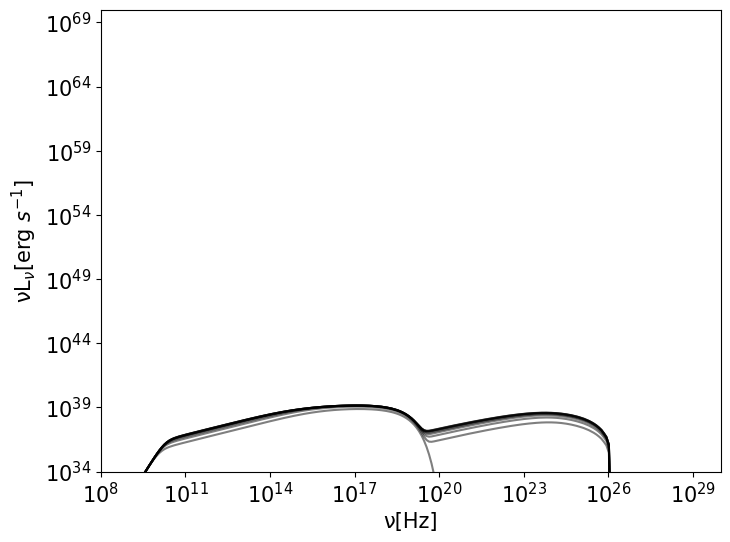

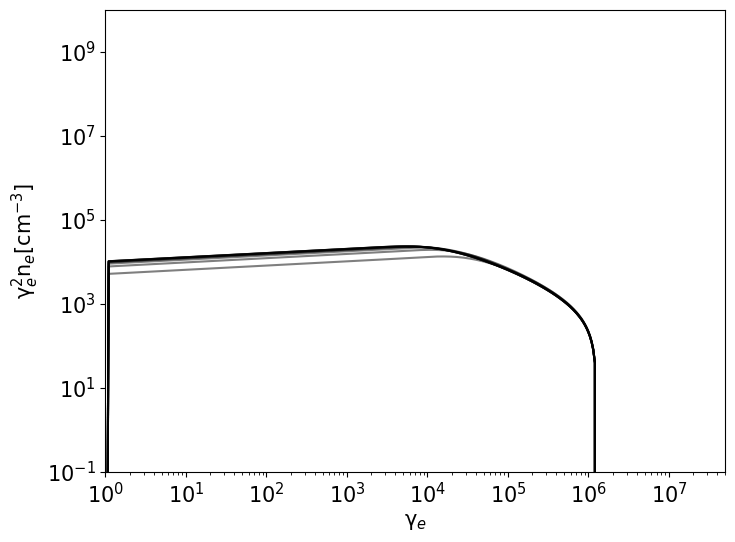

In [23]:
# Read Outpuf files
# LeHaMoC code results
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

El_dis_lemoc_t3 = pd.read_csv("Pairs_Distribution.txt", names=["logx","logy"], sep=" ",  skiprows=0) 
Ph_dis_lemoc_t3 = pd.read_csv("Photons_Distribution.txt", names=["logx","logy"], sep=" ",  skiprows=0) 

nu_tot = np.array(10**Ph_dis_lemoc_t3["logx"])
Spec_temp_tot = np.array(10**Ph_dis_lemoc_t3["logy"])/nu_tot**2.
g_el  = np.array(10**El_dis_lemoc_t3["logx"])
N_el  = np.array(10**El_dis_lemoc_t3["logy"])

# Plots showing time evolution
plotting_evol(nu_tot,Spec_temp_tot,int(grid_nu), 'νL$_{ν}$[erg $s^{-1}$]',"ν[Hz]",10**(8.),10**30.,10**(34.),10**70.,"test1_ph_evol.png")
plotting_evol(g_el, N_el, int(grid_g_el),'γ$_e^2$n$_e$[cm$^{-3}$]',"γ$_{e}$",10**0.,10**7.7,10**(-1.),10**(10.),"test1_el_evol.png")